# Fragment QA: 9.4um midslice + ink-label overlay

For each assembled PHerc0139 training fragment, this shows the 9.362um surface-volume
**midslice** (depth 14 of 28) next to the downloaded **ink label** (resized to the 9.4um
frame) and an **overlay** (ink in hot colors over the grayscale surface). Use it to confirm
the ink label spatially aligns with the papyrus surface we train on.

Fragments with no zarr/inklabels yet (still downloading) are skipped.

In [1]:
import os
import numpy as np
import zarr
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

ZARR_DIR = r"/vesuvius/ves_zarrs2"

# name -> zarr id (segment timestamp). new PHerc0139 training fragments.
FRAGMENTS = {
    "new": "20250628074500"
}


def load_midslice(zid):
    p = os.path.join(ZARR_DIR, f"{zid}.zarr")
    if not os.path.isdir(p):
        return None
    z = zarr.open(p, mode="r")
    return np.asarray(z[z.shape[0] // 2])  # depth-14 midslice


def load_ink(zid):
    p = f"inklabels/{zid}.png"
    if not os.path.exists(p):
        return None
    return np.array(Image.open(p).convert("L"))


def load_mask(zid):
    p = f"masks/{zid}.png"
    if not os.path.exists(p):
        return None
    return np.array(Image.open(p).convert("L")) > 0


print("fragments present:")
for name, zid in FRAGMENTS.items():
    have_z = os.path.isdir(os.path.join(ZARR_DIR, f"{zid}.zarr"))
    have_i = os.path.exists(f"inklabels/{zid}.png")
    print(f"  {name} ({zid}): zarr={'Y' if have_z else '-'}  ink={'Y' if have_i else '-'}")
    

fragments present:
  new (20250628074500): zarr=Y  ink=Y


In [2]:
# one row per fragment: [surface midslice] [ink label] [overlay]
avail = [(n, z) for n, z in FRAGMENTS.items()
         if os.path.isdir(os.path.join(ZARR_DIR, f"{z}.zarr")) and os.path.exists(f"inklabels/{z}.png")]

print(avail)

[('new', '20250628074500')]


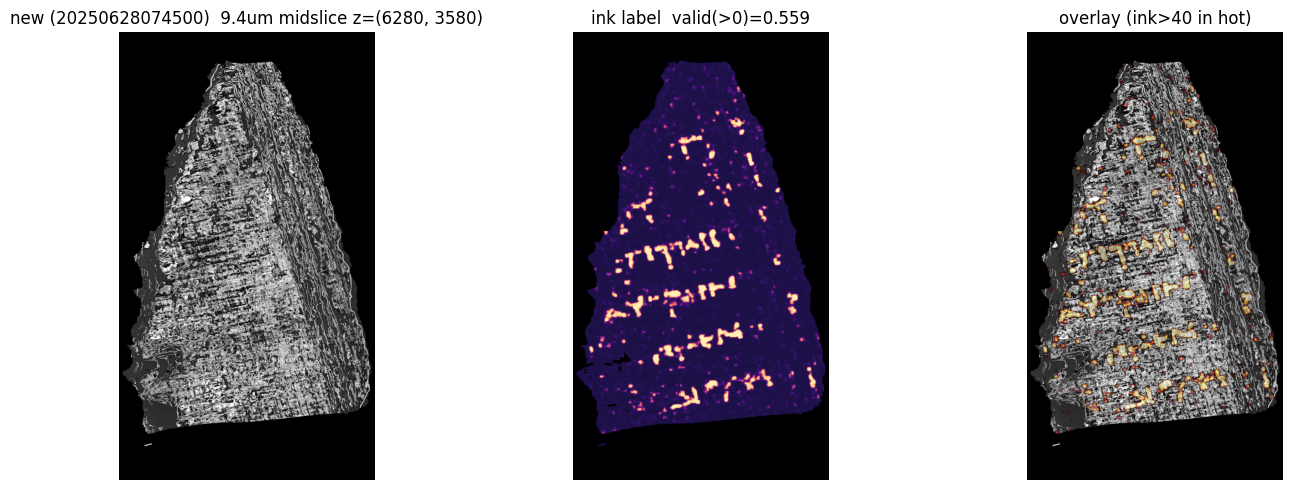

In [3]:
if not avail:
    print("no fragments assembled yet")
else:
    fig, axes = plt.subplots(len(avail), 3, figsize=(15, 5 * len(avail)))
    if len(avail) == 1:
        axes = axes[None, :]
    for row, (name, zid) in enumerate(avail):
        mid = load_midslice(zid).astype(np.float32)
        ink = load_ink(zid).astype(np.float32)
        mask = load_mask(zid)
        # normalize surface for display (2-98 percentile within mask)
        m = mask if mask is not None else (mid > 0)
        lo, hi = np.percentile(mid[m], [2, 98]) if m.any() else (0, 255)
        disp = np.clip((mid - lo) / max(hi - lo, 1), 0, 1)

        axes[row, 0].imshow(disp, cmap="gray")
        axes[row, 0].set_title(f"{name} ({zid})  9.4um midslice z={mid.shape}")
        axes[row, 1].imshow(ink, cmap="magma")
        axes[row, 1].set_title(f"ink label  valid(>0)={ (ink>0).mean():.3f}")
        axes[row, 2].imshow(disp, cmap="gray")
        axes[row, 2].imshow(np.ma.masked_where(ink < 40, ink), cmap="hot", alpha=0.55)
        axes[row, 2].set_title("overlay (ink>40 in hot)")
        for c in range(3):
            axes[row, c].axis("off")
    plt.tight_layout()
    plt.show()